# Mortgage Prepayment Simulation — Monte Carlo and Stochastic Rate Modelling
### Calibrating Interest Rate Models

This is the second notebook of the project **"Mortgage Prepayment Simulation — Monte Carlo and Stochastic Rate Modelling"**

This notebook attempts to calibrate the Cox-Ingersoll-Ross (CIR) Interest Rate Model and Vasicek Model. We first attempt to calibrate the CIR model to estimate all three parameters $\kappa$, $\theta$, and $\sigma$. However, given non mean-reverting nature of the observed rates, we hit a limitation to fit the model. We then attempt to fit a CIR model with fixed $\theta$ parameter. This $\theta$ parameter is estimated from empirical treasury data. 

After calibrating the short-term interest rate models and simulating paths, we simulate the mortgage rate paths. To do this, we fit a linear regression between short-term rates and U.S. 30-year mortgage rates.

The notebook uses the monthly 3-month market treasury yields from January 2015 to December 2024 to calibrate the CIR model. This data is taken from **FRED's DGS3MO** database. For mortgage rates we use the monthly U.S. 30-Year Mortgage Rates for the same time frame. This data is taken from **FRED's MORTGAGE30US** database.


In [2]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import import_ipynb
import importlib
np.random.seed(42)

In [3]:
#Load other notebooks
stochastic_interest_rate_notebook = importlib.import_module('01_StochasticInterestRateModels')

In [4]:
#Load Monthly 3-Month Market Treausry Yields
tsy_yields = pd.read_excel('00_DGS3MO.xlsx')
tsy_yields['DGS3MO'] = tsy_yields['DGS3MO']/100

#Define time step for discretized interest rate model
delta_t = 1/12

In [5]:
if __name__=='__main__':
    #Data Check and Cleaning
    display(tsy_yields.head())

    #Check if rates are 0 or negative
    print(f"There are {tsy_yields[tsy_yields['DGS3MO']<=0].shape[0]} zero or negative rates")

,observation_date,DGS3MO
0,2015-01-01,0.0003
1,2015-02-01,0.0002
2,2015-03-01,0.0003
3,2015-04-01,0.0002
4,2015-05-01,0.0002


There are 0 zero or negative rates


### **Cox-Ingersoll-Ross Model Calibration using OLS**

We first start with calibrating a Cox-Ingersoll-Ross (CIR) model using the mehtod of OLS

The CIR model is defined as:

<div align="center">

$dr_{t} = \kappa(\theta-r_{t})dt + \sigma\sqrt{r_{t}}dW_{t}$

</div>

We discretize this, and convert it into a Linear Regression Model as:

<div align="center">

$r_{t+1}-r_{t}\approx\kappa(\theta-r_{t})\Delta{t}+\sigma\sqrt{r_{t}}e_{t}$,  where $e_{t} \sim N(0,\Delta{t})$

$\frac{r_{t+1}-r_{t}}{\sqrt{r_{t}}} \approx \kappa\theta*\frac{\Delta{t}}{\sqrt{r_{t}}} - \kappa*(\Delta{t}\sqrt{r_{t}}) + \sigma*e_{t}$

</div>

This translates to a linear regression problem as:

<div align="center">

$Y_{t} = \beta_{1}X_{1,t} + \beta_{2}X_{2,t} + \epsilon_{t}$

where, $Y_{t} = \frac{r_{t+1}-r_{t}}{\sqrt{r_{t}}}$ 

$X_{1,t} = \frac{\Delta{t}}{\sqrt{r_{t}}}$ and $\beta_{1} = \kappa\theta$

$X_{2,t} = \Delta{t}\sqrt{r_{t}}$ and $\beta_{2} = -\kappa$

$\sigma e_{t} \sim N(0, \sigma^2\Delta{t})$

</div>



In [6]:
#Define X_{1} and X_{2}
tsy_yields['sqrt{r_t}'] = np.sqrt(tsy_yields['DGS3MO'])
tsy_yields['X_{1}'] = delta_t/tsy_yields['sqrt{r_t}']
tsy_yields['X_{2}'] = delta_t*tsy_yields['sqrt{r_t}']

#Define Y_{t}
y_t = np.zeros((tsy_yields.shape[0],1))
rates = np.array(tsy_yields['DGS3MO'])
for i in range(len(rates)-1):
    y_t[i] = (rates[i+1]-rates[i])/(np.sqrt(rates[i]))
tsy_yields['Y_t'] =y_t

#Drop last observation to fit linear regression
tsy_yields_final = tsy_yields[:tsy_yields.shape[0]-1]

#Fit Linear Regression
X = tsy_yields_final[['X_{1}', 'X_{2}']]
y = tsy_yields_final['Y_t']

#Print Model Summary
model_cir = sm.OLS(y, X).fit()

if __name__=='__main__':    
    print(model_cir.summary())

                                 OLS Regression Results                                
Dep. Variable:                    Y_t   R-squared (uncentered):                   0.058
Model:                            OLS   Adj. R-squared (uncentered):              0.042
Method:                 Least Squares   F-statistic:                              3.614
Date:                Fri, 20 Mar 2026   Prob (F-statistic):                      0.0300
Time:                        18:04:59   Log-Likelihood:                          308.50
No. Observations:                 119   AIC:                                     -613.0
Df Residuals:                     117   BIC:                                     -607.4
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [7]:
#Store the parameters
sigma_param_cir  = np.sqrt(np.var(model_cir.resid)/delta_t)
kappa_param_cir = -model_cir.params['X_{2}']
theta_param_cir = model_cir.params['X_{1}']/kappa_param_cir

if __name__=='__main__':
    #Print the parameters
    print(f"Kappa: {kappa_param_cir:.2f}")
    print(f"Theta: {theta_param_cir:.2f}")
    print(f"Sigma: {sigma_param_cir:.2f}")

Kappa: -0.15
Theta: -0.01
Sigma: 0.06


From the above results we get negative $\kappa$ and $\theta$ this is because of how we have structured the Linear Regression Problem and the model not being able to find a mean reversion pattern in the data. The calibration produced unstable and economically inconsistent parameter estimates, including negative values for the mean reversion speed.

This issue arises because the drift component in the CIR model is weak relative to the stochastic component, particularly in low-rate environments. As a result, the regression-based estimation becomes dominated by noise, leading to unreliable parameter estimates.

We, therefore, can not use these parameters for interest rate path simulation. We now try to fit a Vasicek Model.

### **Vasicek Model Calibration using OLS**

We now try to calibrate a full Vasicek model using the mehtod of OLS

The Vasicek model is defined as:

<div align="center">

$dr_{t} = \kappa(\theta-r_{t})dt + \sigma dW_{t}$

</div>

We discretize this, and convert it into a Linear Regression Model as:

<div align="center">

$r_{t+1} = \theta(1-e^{-(\kappa \Delta{t})}) + e^{-(\kappa \Delta{t})}r_{t} + e_{t}$

</div>

This translates to a linear regression problem as:

<div align="center">

$Y_{t} = a + bX_{t} + \epsilon_{t}$

where, $Y_{t} = r_{t+1}$

$X_{t} = r_{t} \implies b=e^{-(\kappa \Delta{t})} \text{ and } a=\theta(1-b)$

</div>

In [8]:
#Fit Linear Regression
X1 = sm.add_constant(rates[:-1])
y1 = rates[1:]
#Fit the model
model_vasicek = sm.OLS(y1, X1).fit()
#Print sUMMARY
if __name__=='__main__':    
    print(model_vasicek.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 1.159e+04
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          7.00e-119
Time:                        18:04:59   Log-Likelihood:                 573.86
No. Observations:                 119   AIC:                            -1144.
Df Residuals:                     117   BIC:                            -1138.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.587      0.1

In [9]:
#Store the results
a = model_vasicek.params[0]
b = model_vasicek.params[1]
kappa_vasicek = -np.log(b)/delta_t
theta_vasicek = a/(1-b)

if __name__=='__main__':
    #Print the parameters
    print(f"Kappa: {kappa_vasicek:.2f}")
    print(f"Theta: {theta_vasicek:.2f}")

Kappa: 0.02
Theta: 0.29


To address potential instability arising from the square-root diffusion term in the CIR model, the Vasicek model was considered as an alternative due to its linear Gaussian structure and tractable calibration.

However, calibration of the Vasicek model resulted in a near-unit-root behavior (with the autoregressive coefficient close to 1), leading to unrealistically large estimates of the long-term mean. This reflects the fact that recent short-rate data exhibits high persistence and weak mean reversion, making the long-term mean difficult to identify reliably.

These results highlight a structural limitation in short-rate model calibration: the drift component is weakly identifiable from observed data, particularly in prolonged low interest rate regimes.

Consequently, jointly estimating both the speed of mean reversion and the long-term mean leads to unstable and economically implausible parameter values. To adress this, we can try anchoring the $\theta$ parameter to empirical average of observed rates. 

### Cox-Ingersoll-Ross (CIR) Calibration using fixed $\theta$

We now try to calibrate a Cox-Ingersoll-Ross (CIR) model using the mehtod of OLS by fixing $\theta$ at the average of observed short-term rates. 

From above, the discretized CIR model looks like:

<div align="center">

$\frac{r_{t+1}-r_{t}}{\sqrt{r_{t}}} = \kappa\left[\frac{(\theta-r_{t})\Delta{t}}{\sqrt{r_{t}}}\right] + \sigma e_{t}$

</div>

This translates to a linear regression problem as:

<div align="center">

$Y_{t} = \beta X_{t} + \epsilon_{t}$

where, $Y_{t} = \frac{r_{t+1}-r_{t}}{\sqrt{r_{t}}}$

$X_{t} = \frac{(\theta-r_{t})\Delta{t}}{\sqrt{r_{t}}} \text{ and } \kappa = \beta$

</div>

In [10]:
#Fix theta_vasicek
theta = np.mean(tsy_yields['DGS3MO']) 
tsy_yields['X_{1}_fix_theta'] = ((theta - tsy_yields['DGS3MO'])*delta_t)/(np.sqrt(tsy_yields['DGS3MO']))

#Final data
tsy_yields_final_fixed_theta = tsy_yields[:tsy_yields.shape[0]-1]

#Fit Linear Regression
X2 = tsy_yields_final_fixed_theta['X_{1}_fix_theta']
y2 = tsy_yields_final_fixed_theta['Y_t']

#Summary of the model
model_cir_fixed_theta = sm.OLS(y2, X2).fit()

if __name__=='__main__':
    #Print the summary    
    print(model_cir_fixed_theta.summary())

                                 OLS Regression Results                                
Dep. Variable:                    Y_t   R-squared (uncentered):                   0.037
Model:                            OLS   Adj. R-squared (uncentered):              0.029
Method:                 Least Squares   F-statistic:                              4.547
Date:                Fri, 20 Mar 2026   Prob (F-statistic):                      0.0350
Time:                        18:04:59   Log-Likelihood:                          307.18
No. Observations:                 119   AIC:                                     -612.4
Df Residuals:                     118   BIC:                                     -609.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [11]:
#Store the results
kappa_param_cir_fixed_theta = model_cir_fixed_theta.params['X_{1}_fix_theta']
sigma_param_cir_fixed_theta  = np.sqrt(np.var(model_cir_fixed_theta.resid)/delta_t)

if __name__=='__main__':
    #Print the parameters
    print(f"Kappa: {kappa_param_cir_fixed_theta:.2f}")
    print(f"Theta: {theta:.2f}")
    print(f"Sigma: {sigma_param_cir_fixed_theta:.2f}")

Kappa: 0.09
Theta: 0.02
Sigma: 0.06


Given the instability observed in fully calibrated models, a CIR specification with a fixed long-term mean was adopted, resulting in stable and economically plausible parameters ($\kappa = 0.09$, $\theta = 0.02$, $\sigma = 0.06$), which form the basis for subsequent interest rate simulations.

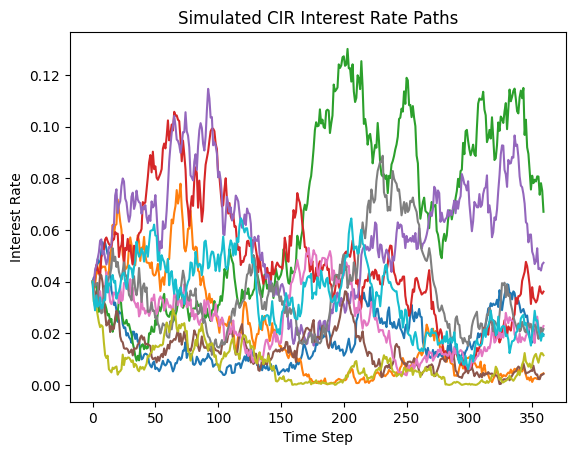

In [12]:
#Simulate using the function already defined in notebook 1
simulated_paths = stochastic_interest_rate_notebook.simulate_paths_based_on_chosen_model(model='CIR',initial_rate=0.04,a=kappa_param_cir_fixed_theta,b=theta,sigma=sigma_param_cir_fixed_theta,T=30,steps=360,number_of_paths=5000)

if __name__=='__main__':
        #Plot the paths
        for i in range(10):
                plt.plot(simulated_paths[i])
        plt.title("Simulated CIR Interest Rate Paths")
        plt.xlabel("Time Step")
        plt.ylabel("Interest Rate")
        plt.show()

The simulated CIR Paths are trying to tend towards zero and in some paths they also turn to 0, this is because in our calibrated CIR model voilates the Feller's conditions. This is a limitation of our calibrated model, for now we proceed ahead with this limitation. We need long-term rates or U.S. 30-Year Mortgage Rate based on these short term rates. 

Long-term rates would be highly correlated with the short-term rates. Though a full methodology might require to use bond pricing formula to estimate the full yield curve, for the purpose of this exercise we can try to fit another linear regression on long-term and short-term rates. We directly use the monthly U.S. 30-Year Mortgage Rate to fit this regression problem. 

In [13]:
#Load 30-year mortgage rates
mortgage_rates_30yrs = pd.read_excel('00_MORTGAGE30US.xlsx')
mortgage_rates_30yrs['MORTGAGE30US'] = mortgage_rates_30yrs['MORTGAGE30US']/100

#Merge short-term and mortgage-rates dataset
merged_data = pd.merge(mortgage_rates_30yrs, tsy_yields, on='observation_date')[['MORTGAGE30US','DGS3MO']]

#Fit a linear regression
X3 = sm.add_constant(merged_data['DGS3MO'])
y3 = merged_data['MORTGAGE30US']

#Fit the model
model_long_term_rates = sm.OLS(y3, X3).fit()
if __name__=='__main__':
    #Print Model summary
    print(model_long_term_rates.summary())

                            OLS Regression Results                            
Dep. Variable:           MORTGAGE30US   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     895.4
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           6.17e-57
Time:                        18:05:01   Log-Likelihood:                 474.01
No. Observations:                 120   AIC:                            -944.0
Df Residuals:                     118   BIC:                            -938.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0328      0.001     55.643      0.0

The p-values on both the parameters are 0 meaning there is enough evidence that suggests both the parameter are significant enough to be included in the regression analysis. Overall, the R-Squared is 88.4% which means the model has good accuracy. We use this model to simualte mortgage rates using the simulated short-term rates.

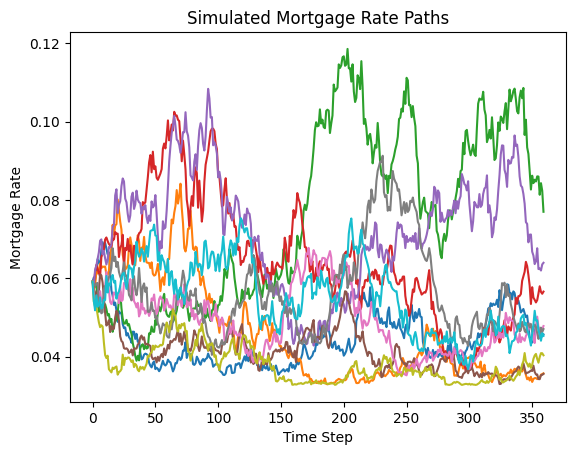

In [15]:
#Extract parameters
intercept = model_long_term_rates.params['const']
beta = model_long_term_rates.params['DGS3MO']

#Simulate 30-year mortgage rates using simulates short-term rates
simulated_mortgage_rates = intercept+beta*simulated_paths

#Plot sample paths of mortgage rates
if __name__=='__main__':
    #Plot the paths
    for i in range(10):
            plt.plot(simulated_mortgage_rates[i])
    plt.title("Simulated Mortgage Rate Paths")
    plt.xlabel("Time Step")
    plt.ylabel("Mortgage Rate")
    plt.show()

In few of the paths we see rates converging towards 3% which is the long-term mortgage rate assumption from our linear regression. The simulated short-term rate in these cases is likely to be around 0 because of the limitation of Feller's condition not being met in our CIR Calibration. 

### End of Notebook